# How concentrated is St. Petersburg's mapped park area?

The checked `stpete-parks` layer has park polygons, including preserves and a golf course. This story asks what share of the **sum of mapped polygon area** comes from the ten largest features. It uses a local projected CRS for area, retrieves every matching row, and checks the package's completeness record before drawing a chart.

**Source:** [City of St. Petersburg Parks layer](https://services2.arcgis.com/9qPLjNtocjo438CJ/arcgis/rest/services/Parks_view/FeatureServer/0) and [publisher item](https://csp.maps.arcgis.com/home/item.html?id=ff0015e3a49044ecbbd7a758e8098076). Run with an R kernel and the `tampaBayOpenData` and `sf` packages. The live source can change between runs.

In [1]:
library(tampaBayOpenData)
library(sf)

info <- tbod_dataset_info("stpete-parks")
cat(info$publisher, "|", info$title, "\nSource:", info$source_url, "\n")

Warning message:
"package 'sf' was built under R version 4.5.3"


Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE



City of St. Petersburg | St. Petersburg parks 
Source: https://csp.maps.arcgis.com/home/item.html?id=ff0015e3a49044ecbbd7a758e8098076 


## Retrieve the complete layer

Request geometry in EPSG:26917 (UTM zone 17N), whose metre coordinates support local area calculation. The checked entry verifies the upstream schema, and full retrieval validates the object-ID manifest.

In [2]:
parks <- tbod_get_dataset(
  "stpete-parks",
  fields = c("OBJECTID", "NAME", "FULLADDR"),
  spatial = TRUE, out_sr = 26917, limit = Inf
)
p <- tbod_provenance(parks)
stopifnot(isTRUE(p$complete), p$matched_rows == nrow(parks),
          p$returned_rows == nrow(parks), sf::st_crs(parks)$epsg == 26917)
print(data.frame(retrieved_at_utc = format(p$retrieved_at, tz = "UTC"),
                 matched_rows = p$matched_rows, returned_rows = p$returned_rows,
                 complete = p$complete, integrity = p$integrity))

     retrieved_at_utc matched_rows returned_rows complete     integrity
1 2026-10-06 22:39:06          182           182     TRUE full-manifest


## Rank polygon footprints

Area is calculated from the returned geometries, not the service's stored area field. A row is a mapped polygon; this is not a measure of public access, facilities, or area per resident.

In [3]:
area_ha <- as.numeric(sf::st_area(parks)) / 10000
stopifnot(all(is.finite(area_ha)), all(area_ha > 0))
ranked <- data.frame(name = parks$NAME, area_ha = area_ha)
ranked <- ranked[order(ranked$area_ha, decreasing = TRUE), ]
print(data.frame(polygons = nrow(ranked), unique_names = length(unique(ranked$name)),
                 median_hectares = round(median(ranked$area_ha), 2),
                 top_ten_area_share = round(sum(head(ranked$area_ha, 10)) /
                                              sum(ranked$area_ha), 3)))
print(transform(head(ranked, 10), area_ha = round(area_ha, 2)), row.names = FALSE)

  polygons unique_names median_hectares top_ten_area_share
1      182          182            1.38              0.496


                       name area_ha
  BOYD HILL NATURE PRESERVE  166.07
   MANGROVE BAY GOLF COURSE   80.76
         WALTER FULLER PARK   34.97
 CLAM BAYOU NATURE PRESERVE   34.28
         CRESCENT LAKE PARK   17.21
          JACK PURYEAR PARK   17.03
            LAKE VISTA PARK   15.78
                MAXIMO PARK   15.25
              BARTLETT PARK   14.69
                AZALEA PARK   14.58


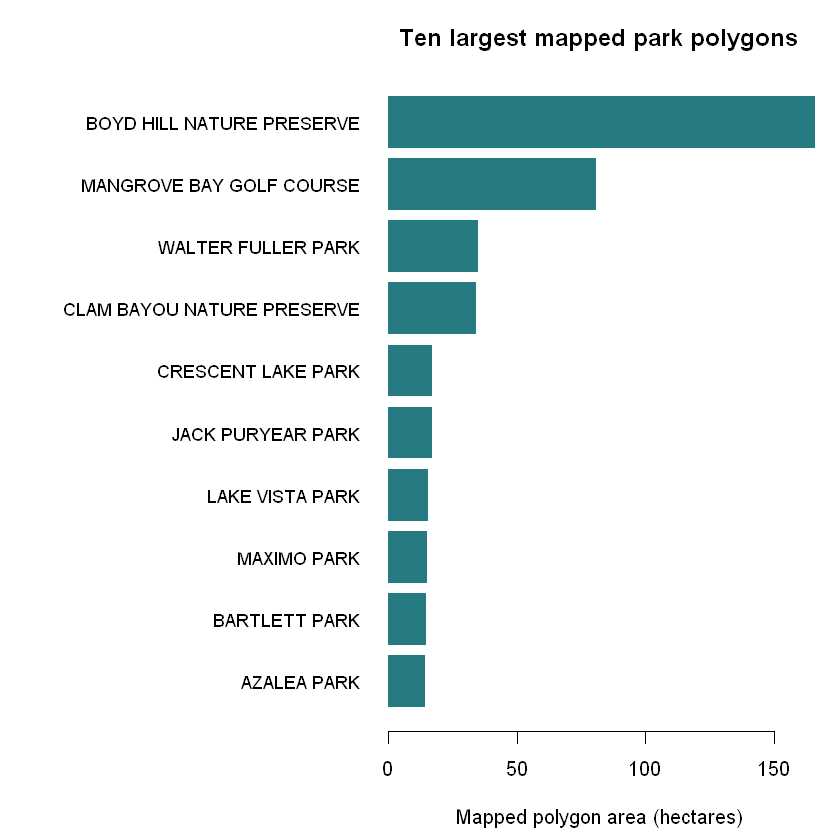

In [4]:
top_ten <- head(ranked, 10)
old_par <- par(mar = c(4.5, 16, 3, 1))
barplot(rev(top_ten$area_ha), names.arg = rev(top_ten$name), horiz = TRUE,
        las = 1, cex.names = 0.9, col = "#267B82", border = NA,
        xlab = "Mapped polygon area (hectares)",
        main = "Ten largest mapped park polygons")
par(old_par)

The largest mapped features include nature preserves and a golf course. The sum can double-count overlap if polygons overlap; it is not a dissolved land-cover estimate. A new run should report the current ten features and share instead of assuming the saved ranking still holds.